In [1]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Union, Tuple, List
from utils import ImageBatchGenerator, ManualConvLayer,Flatten,SigmoidAct,TanhAct,SGDOptimizer,\
            ReluAct,SoftmaxAct,PoolingLayer,CategoricalCrossEntropyLoss,DenseLayer,Flatten2
from PIL import Image

In [2]:
dogs_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\dog"
cats_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\cat"

In [3]:

batch_generator = ImageBatchGenerator({"dog":dogs_path, "cat":cats_path},batch_size=2,network_input_size=(100,100))
for i,batch in enumerate(batch_generator):
    
    print(batch_generator.batch_size)
    if i>=5:
        break



n_samples 653
2
2
2
2
2
2


In [4]:
(val_batch,val_labels),(test_batch,test_labels) = batch_generator.return_val_test_batches()

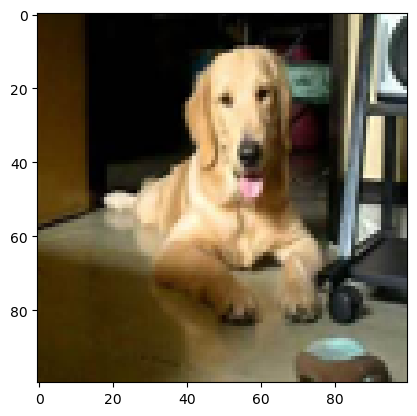

In [5]:
plt.imshow(val_batch[:,:,:,0])

### now lets run our minibatch train-eval loop

In [6]:
batch_size = 2

n_iters = 10
n_epochs = 100
lr = 0.1
lr_decay_rate = 0.001
momentum = 0.5
n_dense_inputs = 177504 # needs to be calculated
n_dense_neurons = 64
n_class = 2 # dog or cat
Conv1 = ManualConvLayer((5,5),6)
Conv2 = ManualConvLayer((5,5),12)
Conv3 = ManualConvLayer((5,5),24)

pooling1 = PoolingLayer("max",(2,2),stride=1)
pooling2 = PoolingLayer("max",(2,2),stride=1)

dense1 = DenseLayer(n_dense_inputs,n_dense_neurons)
dense2 = DenseLayer(n_dense_neurons,n_class)

flatten_layer = Flatten2()
tanh_acts = [TanhAct() for _ in range(4)]
softmax_act = SoftmaxAct()
loss = CategoricalCrossEntropyLoss()
optimizer = SGDOptimizer(lr,lr_decay_rate,momentum)

total_iter = n_iters*n_epochs
history = np.zeros((total_iter,3))

for epoch in range(n_epochs):
    for i,batch in enumerate(batch_generator):
        if i>=n_iters:
            break
        # forward pass
        out = Conv1.forward(batch)
        out = tanh_acts[0].forward(out)
        out = pooling1.forward(out)
        out = Conv2.forward(out)
        out = tanh_acts[1].forward(out)
        out = pooling2.forward(out)
        out = Conv3.forward(out)
        out = tanh_acts[2].forward(out)
        print("conv layers passed successfully")
        out = flatten_layer.forward(out)
        n_dense_inputs = out.shape[0]
        dense1.n_inputs = n_dense_inputs
        out = dense1.forward(out)
        out = tanh_acts[3].forward(out)
        out = dense2.forward(out)
        out = softmax_act.forward(out)
        gt = np.where(batch_generator.batch_labels == "dog", 0, 1)
        loss_val = loss.forward(out,gt)
        acc = np.mean(np.argmax(out,axis=1) == gt)
        history[epoch*n_iters+i] = [np.mean(loss_val),acc,optimizer.current_learning_rate]
        print("forward pass passed successfully")
        # backward pass
        grad = loss.backward(loss_val)
        grad = softmax_act.backward(grad)
        grad = dense2.backward(grad)
        grad = tanh_acts[3].backward(grad)
        grad = dense1.backward(grad)
        grad = flatten_layer.backward(grad)
        grad = tanh_acts[2].backward(grad)
        grad = Conv3.backward(grad)
        grad = pooling2.backward(grad)
        grad = tanh_acts[1].backward(grad)
        grad = Conv2.backward(grad)
        grad = pooling1.backward(grad)
        grad = tanh_acts[0].backward(grad)
        grad = Conv1.backward(grad)

        optimizer.pre_params_update()
        for layer in [Conv1,Conv2,Conv3,dense1,dense2]:
            optimizer.update_params(layer)
        optimizer.post_params_update()
        print(f"epoch:{epoch}, iter:{i}, loss:{np.mean(loss_val)}, acc:{acc}, lr:{optimizer.current_learning_rate}")






batch_size 2
img_channels 6
FINISHED element 0/2
FINISHED element 1/2
batch_size 2
img_channels 12
FINISHED element 0/2
FINISHED element 1/2
conv layers passed successfully
forward pass passed successfully
epoch:0, iter:0, loss:[0.46146426 0.15786269], acc:1.0, lr:0.1
batch_size 2
img_channels 6
FINISHED element 0/2
FINISHED element 1/2
batch_size 2
img_channels 12
FINISHED element 0/2
FINISHED element 1/2
conv layers passed successfully
forward pass passed successfully
epoch:0, iter:1, loss:[1.44306256e+01 1.97026466e-06], acc:0.5, lr:0.09990009990009992
batch_size 2
img_channels 6
FINISHED element 0/2
FINISHED element 1/2
batch_size 2
img_channels 12
FINISHED element 0/2
FINISHED element 1/2
conv layers passed successfully
forward pass passed successfully
epoch:0, iter:2, loss:[3.64127910e-05 1.61180957e+01], acc:0.5, lr:0.0998003992015968
batch_size 2
img_channels 6
FINISHED element 0/2
FINISHED element 1/2
batch_size 2
img_channels 12
FINISHED element 0/2
FINISHED element 1/2
conv 

KeyboardInterrupt: 

In [9]:
loss_val

array([2.46518850e+00, 2.60671224e-05])